In [17]:
import os
import pandas as pd
import sqlalchemy as db
from dotenv import load_dotenv
import matplotlib.pyplot as plt

## Corporate Bond Trading: Finding the Customers' Yachts

Exhibit replication of research by Maureen O’Hara and Xing (Alex) Zhou.

In [18]:
load_dotenv()

# config and credentials
server = os.getenv('DB_SERVER')
database = os.getenv('DB_NAME')
username = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')

# connection
engine = db.create_engine(
    'mssql://{}:{}@{}/{}?driver=ODBC+Driver+18+for+SQL+Server'.format(
        username, password, server, database
    )
)

# establish connection
connection = engine.connect()

### Exhibit 1

In [19]:
# read sql
# ending year is excluded!
# df1 = pd.read_sql('EXEC dbo.sp_TradeVolumeByInvestmentGrade @StartYear = 2002, @EndYear = 2024', connection)

# store csv
# df1.to_csv('data/TradeVolumeByInvestmentGrade.csv', index=False)

# read csv
df1 = pd.read_csv('data/TradeVolumeByInvestmentGrade.csv')

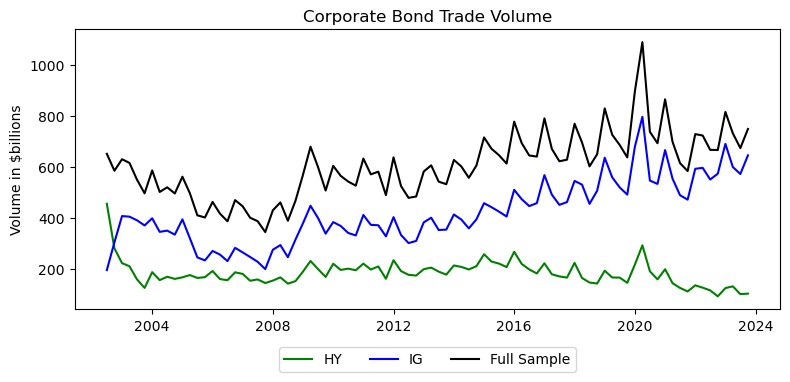

In [20]:
# parse dates
df1['TrdExctnQrDt'] = pd.to_datetime(df1['TrdExctnQrDt'])

# pivot
pivot_df = df1.pivot_table(
    index='TrdExctnQrDt',
    columns='InvestGrade',
    values='TotalVolume',
    aggfunc='sum'
)

# values in billions
pivot_df = pivot_df / 1e9

# plot
plt.figure(figsize=(8, 4))
colors = {'IG': 'blue', 'HY': 'green'}
for column in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[column], label=column, color=colors.get(column))

# compute total values across categories
total_series = pivot_df.sum(axis=1)
plt.plot(pivot_df.index, total_series, color='black', label='Full Sample')

# legend
plt.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    frameon=True
)

# labels
plt.ylabel('Volume in $billions')
plt.title('Corporate Bond Trade Volume')
plt.tight_layout()
plt.show()

### Exhibit 2

In [21]:
# read sql
# ending year is excluded!
# df2 = pd.read_sql('EXEC dbo.sp_TradesBySizeCategory @StartYear = 2002, @EndYear = 2024', connection)

# store csv
# df2.to_csv('data/TradesBySizeCategories.csv', index=False)

# read csv
df2 = pd.read_csv('data/TradesBySizeCategories.csv')

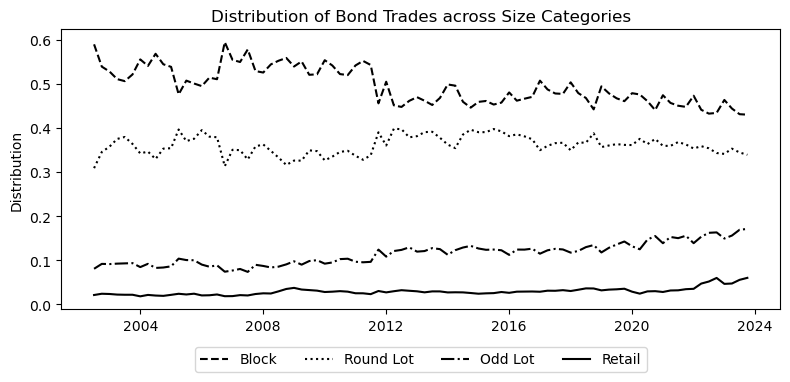

In [22]:
# parse dates
df2['TrdExctnQrDt'] = pd.to_datetime(df2['TrdExctnQrDt'])

# pivot
pivot_df = df2.pivot_table(
    index='TrdExctnQrDt',
    columns='SizeCategory',
    values='TotalVolume',
    aggfunc='sum'
)

# compute total
total_series = pivot_df.sum(axis=1)

# calculate ratios
df_ratios = pivot_df.div(total_series, axis=0)

# plot
plt.figure(figsize=(8, 4))
linestyles = {'Block': '--', 'Odd Lot': '-.', 'Round Lot': ':', 'Retail': '-'}
for column in df_ratios.columns:
    plt.plot(df_ratios.index, df_ratios[column], label=column, color='black', linestyle=linestyles.get(column))

# legend
handles, labels = plt.gca().get_legend_handles_labels()
label_to_handle = dict(zip(labels, handles))
desired_order = ['Block', 'Round Lot', 'Odd Lot', 'Retail']
ordered_handles = [label_to_handle[label] for label in desired_order]
plt.legend(
    ordered_handles, desired_order,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=4,
    frameon=True
)

# labels
plt.ylabel('Distribution')
plt.title('Distribution of Bond Trades across Size Categories')
plt.tight_layout()
plt.show()

### Exhibit 3

In [23]:
# read sql
# ending year is excluded!
# df3 = pd.read_sql('EXEC dbo.sp_TransactionCosts @StartYear = 2002, @EndYear = 2024', connection)

# store csv
# df3.to_csv('data/TransactionCosts.csv', index=False)

# read csv
df3 = pd.read_csv('data/TransactionCosts.csv')

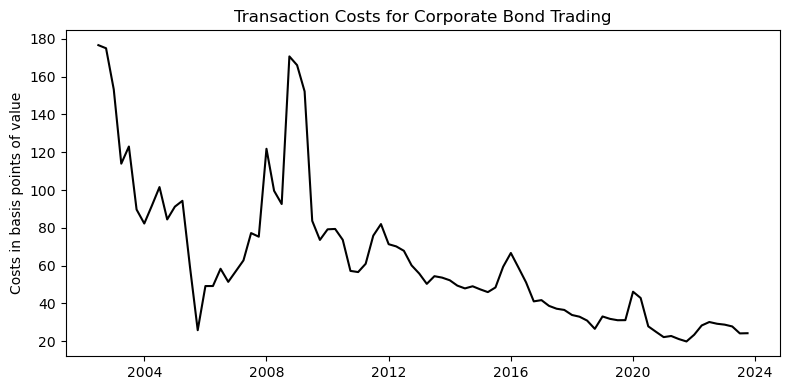

In [24]:
# parse dates
df3['TrdExctnQrDt'] = pd.to_datetime(df3['TrdExctnQrDt'])

# plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df3['TrdExctnQrDt'], df3['TransactionCosts'], color='black')
ax.set_ylabel('Costs in basis points of value')
ax.set_title('Transaction Costs for Corporate Bond Trading')
plt.tight_layout()
plt.show()

### Exhibit 4

In [ ]:
# read sql
# ending year is excluded!
# df4 = pd.read_sql('EXEC dbo.sp_TransactionCostsBySizeCategory @StartYear = 2002, @EndYear = 2024', connection)

# store csv
# df4.to_csv('data/TransactionCostsBySizeCategory.csv', index=False)

# read csv
df4 = pd.read_csv('data/TransactionCostsBySizeCategory.csv')

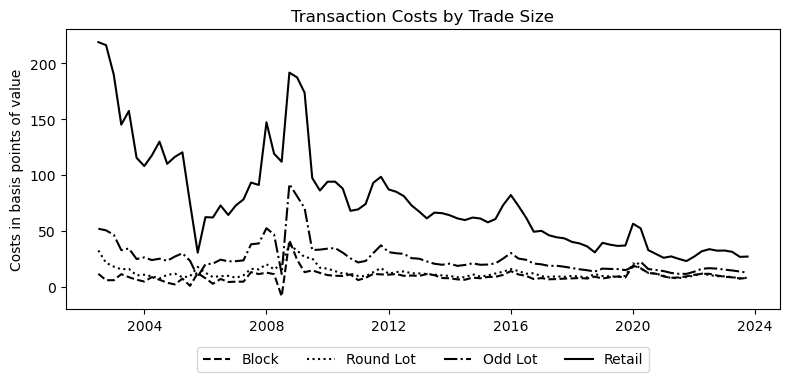

In [26]:
# parse dates
df4['TrdExctnQrDt'] = pd.to_datetime(df4['TrdExctnQrDt'])

# pivot
pivot_df = df4.pivot_table(
    index='TrdExctnQrDt',
    columns='SizeCategory',
    values='TransactionCosts',
    aggfunc='sum'
)

# plot
plt.figure(figsize=(8, 4))
linestyles = {'Block': '--', 'Odd Lot': '-.', 'Round Lot': ':', 'Retail': '-'}
for column in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[column], label=column, color='black', linestyle=linestyles.get(column))

# legend
handles, labels = plt.gca().get_legend_handles_labels()
label_to_handle = dict(zip(labels, handles))
desired_order = ['Block', 'Round Lot', 'Odd Lot', 'Retail']
ordered_handles = [label_to_handle[label] for label in desired_order]
plt.legend(
    ordered_handles, desired_order,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=4,
    frameon=True
)

# labels
plt.ylabel('Costs in basis points of value')
plt.title('Transaction Costs by Trade Size')
plt.tight_layout()
plt.show()